In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
import copy
import io
import os
import queue
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date

import matplotlib.cm as cm
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather

from aquacrop_slovenia import config
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_gdd_and_yield, \
    plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameters_running_rakican import rakican_soil_layers, rakican_curve_number, \
    rakican_readily_evaporable_water, rakican_maize_params, rakican_optimal_management, rakican_initial_cond, \
    rakican_groundwater
from aquacrop_slovenia.diagnostics import nse, kge, mkge

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
# Set up working directory for outputs
output_dir = config.MODEL_RUNNING_DIR / "testing_daily_rakican"
LOCATION = "rakican"

In [4]:
# Single year for daily inspection. Excluded years: 1998, 2023, 2017.
year = 2003
simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 4, 20),
        "is_seeding_year": True,
    }
]

In [5]:
rakican_temperatures, rakican_eto, rakican_rain = get_station_weather(355)  # Rakičan uses ARSO meteo station 355

In [6]:
historical_co2 = get_co2_for_aquacrop("historical")

In [7]:
rakican_weather = Weather(
    location=LOCATION,
    temperatures=rakican_temperatures,
    eto_values=rakican_eto,
    rainfall_values=rakican_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2
)

In [8]:
rakican_maize = Crop(
    name=f"{LOCATION} maize",
    description=f"{LOCATION} maize uncalibrated",
    params=rakican_maize_params
)

In [9]:
rakican_soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil uncalibrated",
    soil_layers=rakican_soil_layers,
    curve_number=rakican_curve_number,
    readily_evaporable_water=rakican_readily_evaporable_water
)

In [10]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=rakican_maize,
    soil=rakican_soil,
    management=rakican_optimal_management,
    initial_conditions=rakican_initial_cond,
    climate=rakican_weather,
    #ground_water=rakican_groundwater,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [11]:
# Run the simulation
results = simulation.run()
seasonal_results = results["season"]

Setting up working directory at: E:\aquacrop\testing_daily_rakican
Running AquaCrop simulation with project file: E:\aquacrop\testing_daily_rakican\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: E:\aquacrop\testing_daily_rakican\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [12]:
seasonal_results

,RunNr,Day1,Month1,Year1,Rain,ETo,GD,CO2,Irri,Infilt,...,HI,Y(dry),Y(fresh),WPet,Bin,Bout,DayN,MonthN,YearN,Project
0,1,1,1,2003,514.7,857.7,1629.6,374.22,0.0,503.6,...,46.7,4.123,4.968,1.81,0.0,0.0,31,12,2003,PROJECT.PRM


In [13]:
results["day"]

,Day,Month,Year,DAP,Stage,WC(1.20),Rain,Irri,Surf,Infilt,...,9_1,ECe10,ECe11,ECe12,Rain_1,ETo,Tmin,Tavg,Tmax,CO2
0,1,1,2003,-9,0,263.3,3.9,0.0,0.0,3.9,...,None,None,None,None,None,None,None,None,None,None
1,2,1,2003,-9,0,262.2,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
2,3,1,2003,-9,0,261.3,0.2,0.0,0.0,0.2,...,None,None,None,None,None,None,None,None,None,None
3,4,1,2003,-9,0,260.1,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
4,5,1,2003,-9,0,259.5,0.9,0.0,0.0,0.9,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,27,12,2003,-9,0,258.7,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
361,28,12,2003,-9,0,258.0,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
362,29,12,2003,-9,0,257.5,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
363,30,12,2003,-9,0,258.9,1.9,0.0,0.0,1.9,...,None,None,None,None,None,None,None,None,None,None


<Axes: >

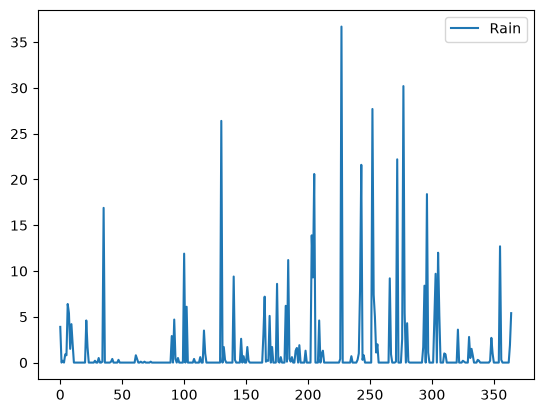

In [14]:
results["day"].plot(y="Rain")

<Axes: >

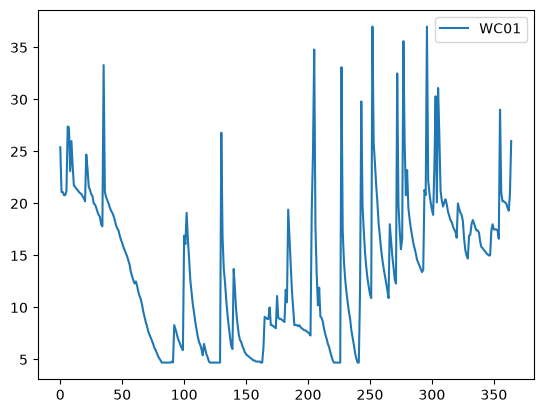

In [15]:
results["day"].plot(y="WC01")

In [16]:
#results["day"].plot(y="WC(2.00)")

<Axes: >

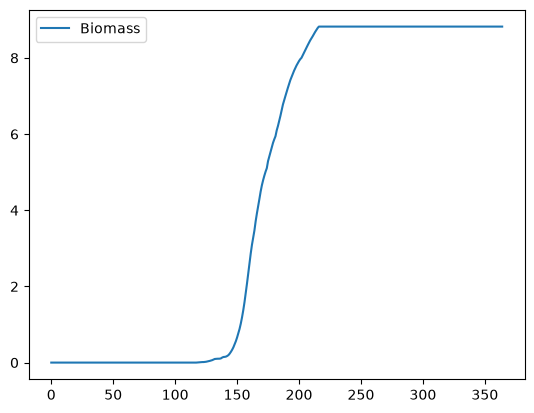

In [17]:
results["day"].plot(y="Biomass")

<Axes: >

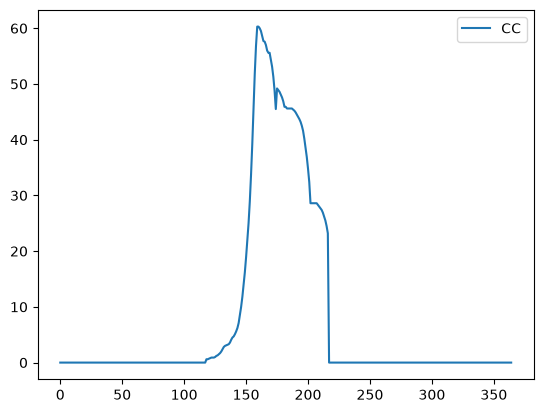

In [18]:
results["day"].plot(y="CC")

<Axes: >

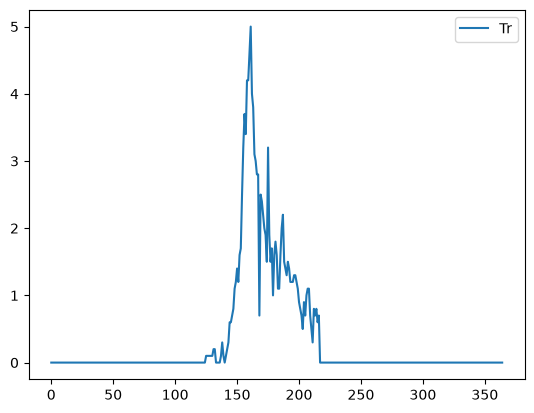

In [19]:
results["day"].plot(y="Tr")

<Axes: >

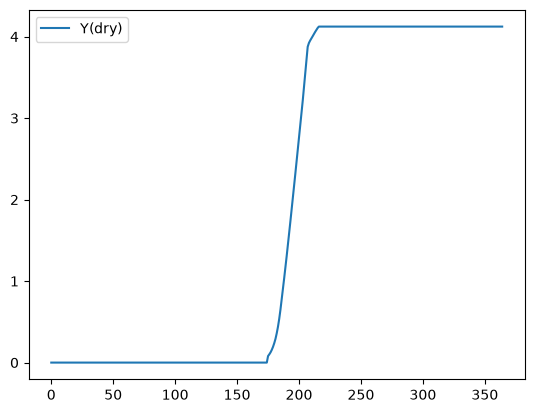

In [20]:
results["day"].plot(y="Y(dry)")

In [21]:
# GDD parameter sensitivity sweep — one param at a time, five values each
# Defaults: gdd_emergence=38, gdd_max_rooting=1207, gdd_senescence=1193,
#           gdd_maturity=1466, gdd_cycle_length=1466, gdd_flowering=660,
#           gdd_flowering_length=164, gdd_hi_start=595
gdd_sweep_params = {
    "gdd_emergence":        [20, 29, 38, 47, 56],
    "gdd_max_rooting":      [1025, 1116, 1207, 1298, 1390],
    "gdd_senescence":       [1000, 1097, 1193, 1290, 1385],
    "gdd_maturity":         [1245, 1356, 1466, 1576, 1685],
    "gdd_cycle_length":     [1265, 1366, 1466, 1566, 1666],
    "gdd_flowering":        [550, 605, 660, 715, 770],
    "gdd_flowering_length": [115, 140, 164, 188, 212],
    "gdd_hi_start":         [480, 538, 595, 652, 710],
}

INTEGER_PARAMS = {name for name, val in rakican_maize_params.items() if isinstance(val, int)}

MAX_WORKERS = os.cpu_count()
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.MODEL_RUNNING_DIR / f"daily_gdd_rakican_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

gdd_dir_queue = queue.Queue()
for d in worker_dirs:
    gdd_dir_queue.put(d)


def run_gdd_param(param_name, value):
    working_dir = gdd_dir_queue.get()
    try:
        params = copy.deepcopy(rakican_maize_params)
        params[param_name] = int(round(value)) if param_name in INTEGER_PARAMS else float(value)
        crop = Crop(name=f"{LOCATION} maize", description=f"{param_name}={value}", params=params)
        sim = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=rakican_soil,
            management=rakican_optimal_management,
            initial_conditions=rakican_initial_cond,
            climate=rakican_weather,
            #ground_water=rakican_groundwater,
            working_dir=working_dir,
            need_daily_output=True,
            need_seasonal_output=False,
            need_harvest_output=False,
            need_evaluation_output=False,
        )
        with contextlib.redirect_stdout(io.StringIO()):
            res = sim.run()
        daily = res["day"]
        return param_name, value, daily[daily["DAP"] >= 0].copy()
    finally:
        gdd_dir_queue.put(working_dir)


gdd_daily_results = {name: {} for name in gdd_sweep_params}

tasks = [(name, val) for name, values in gdd_sweep_params.items() for val in values]
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(run_gdd_param, name, val) for name, val in tasks]
    for future in as_completed(futures):
        param_name, value, daily = future.result()
        gdd_daily_results[param_name][value] = daily

print("Done.")

Results successfully parsed


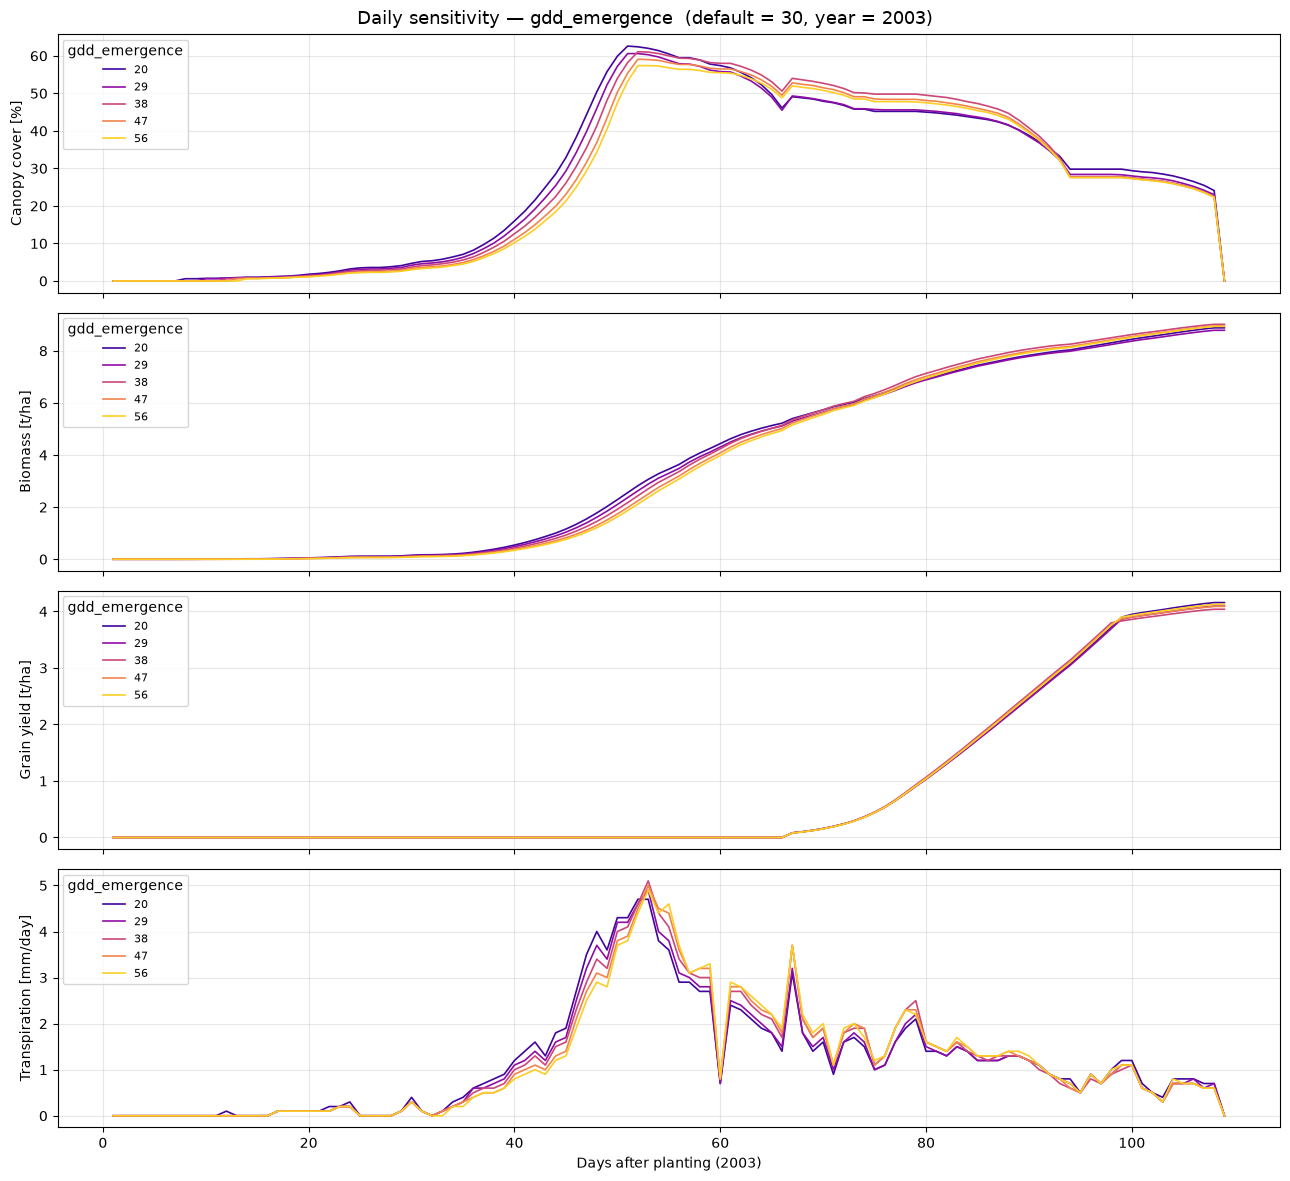

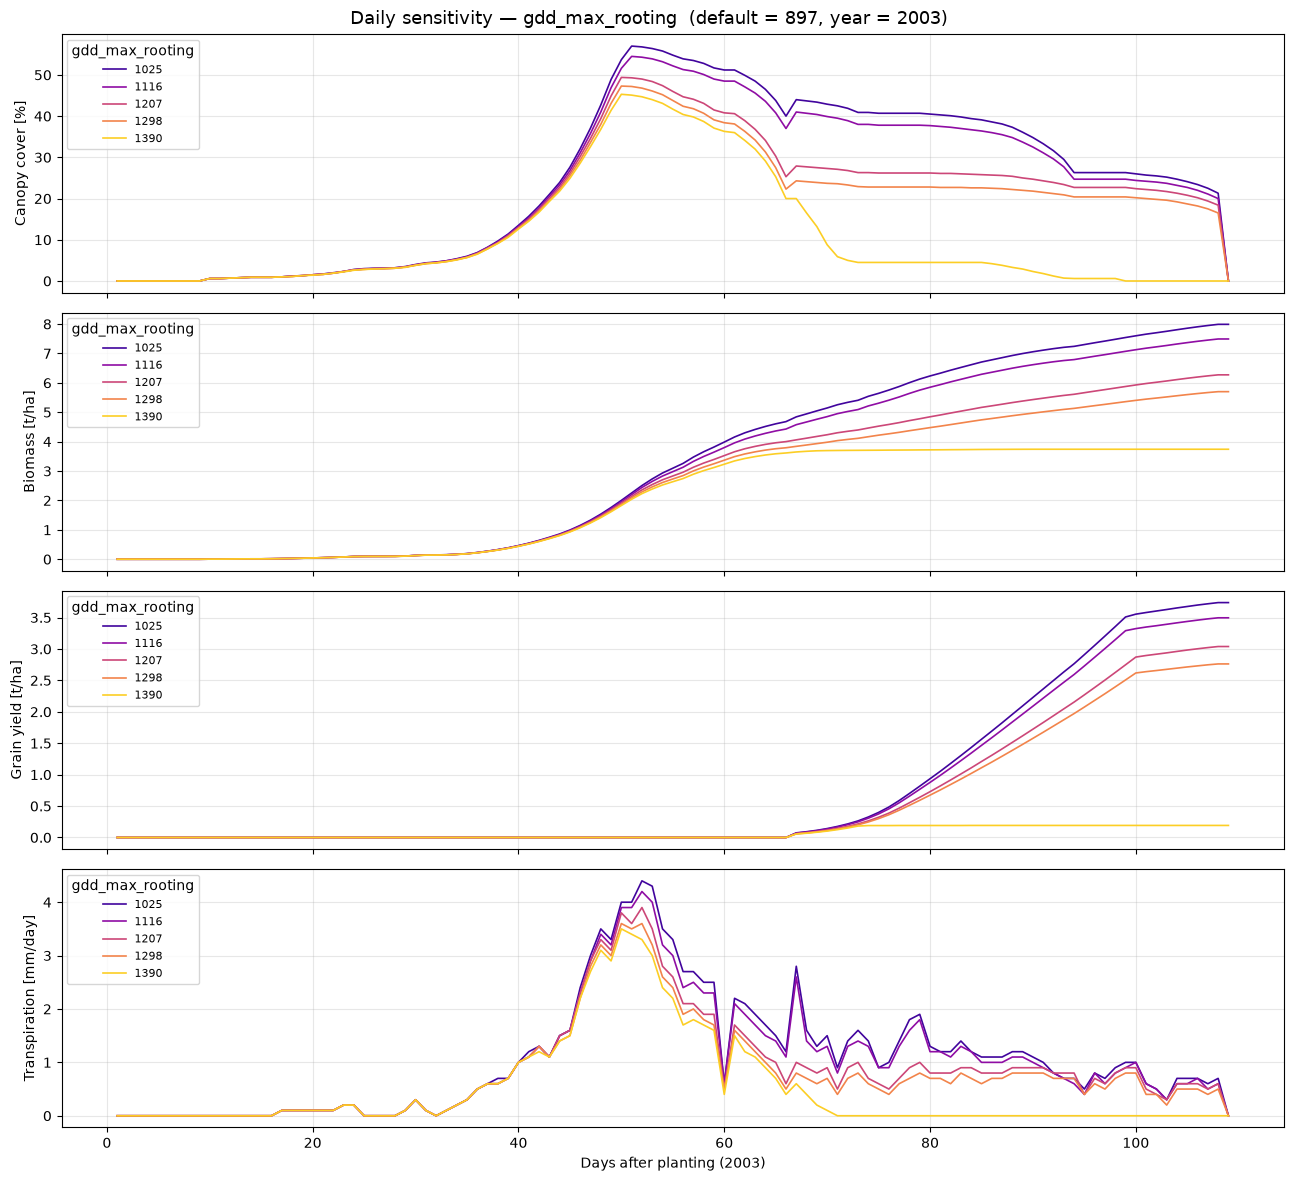

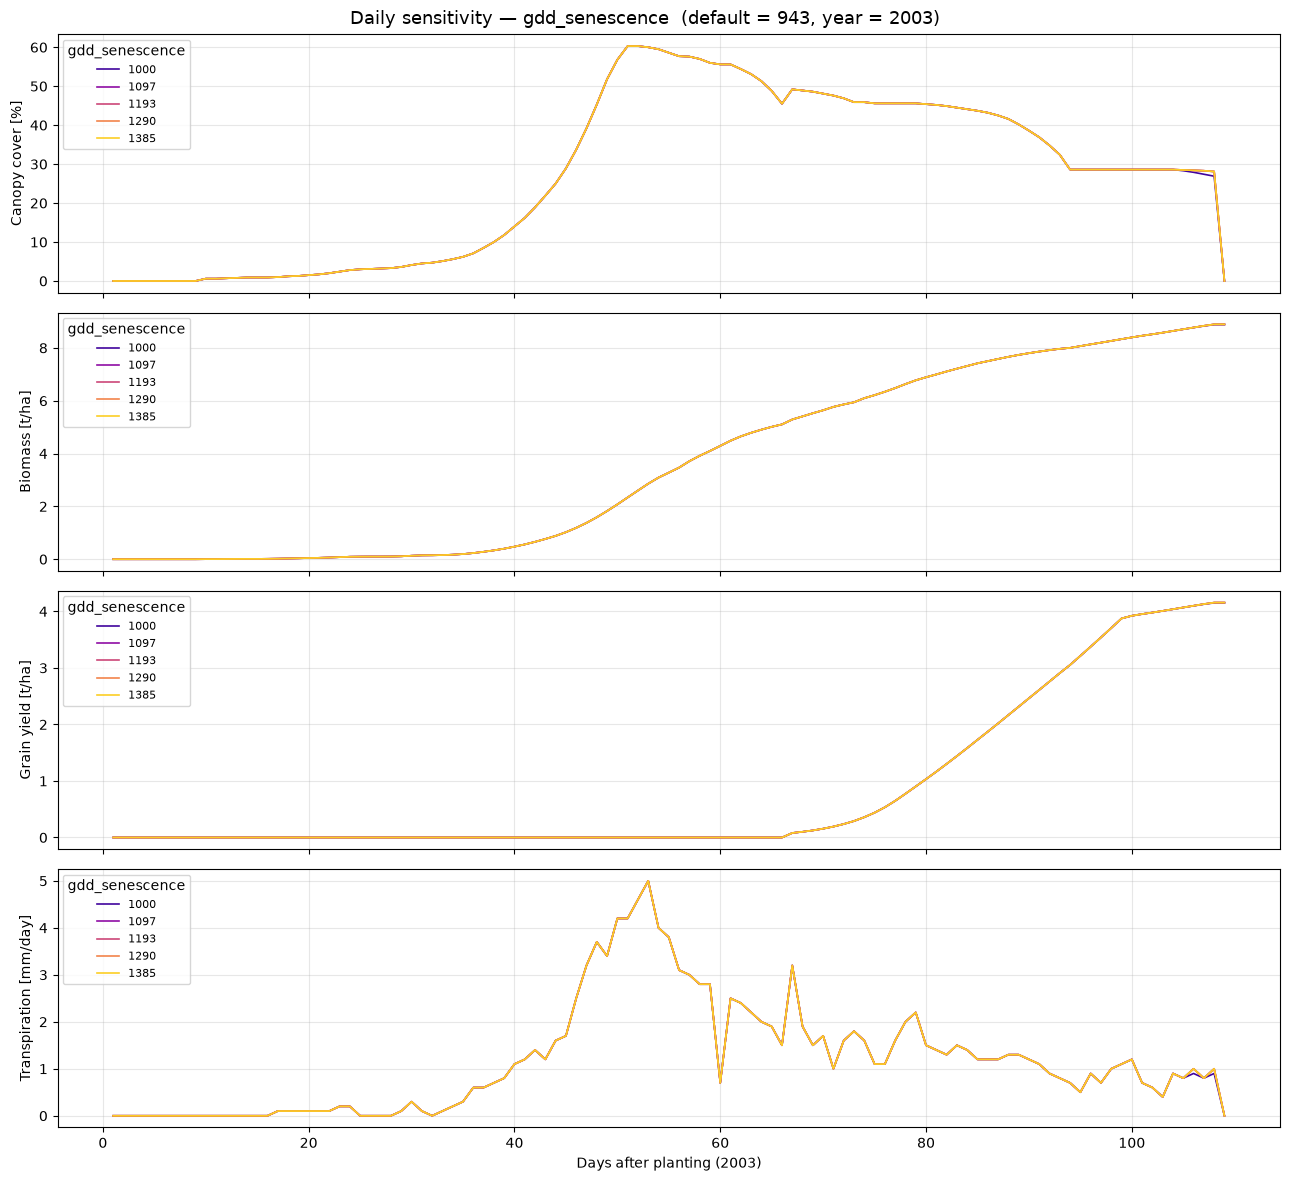

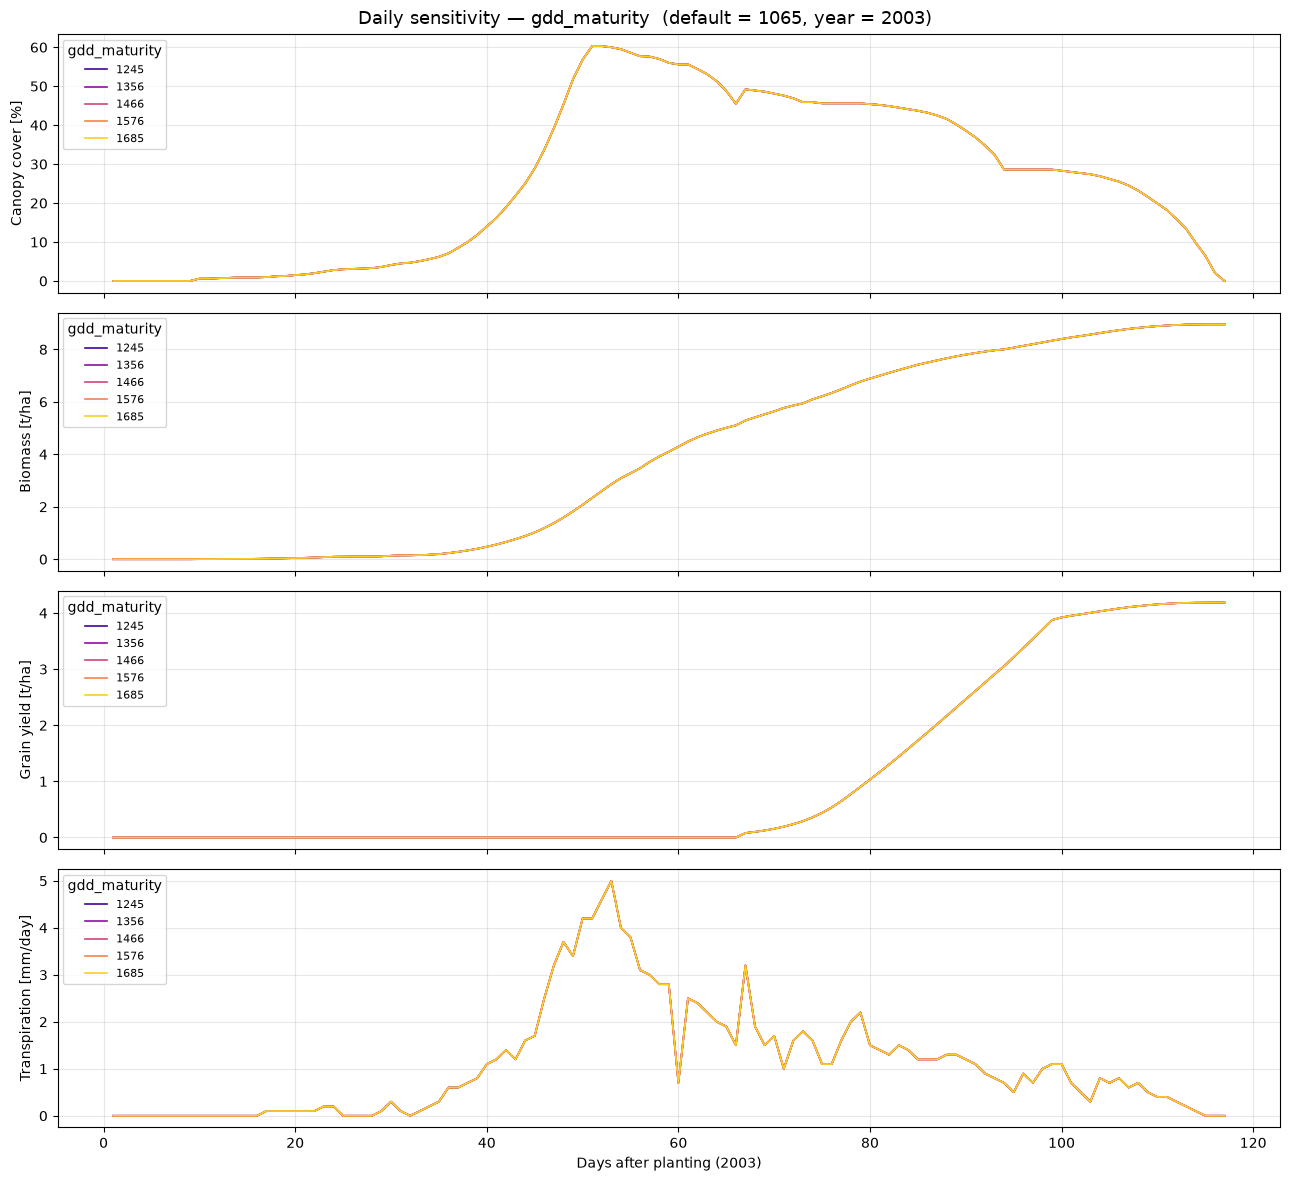

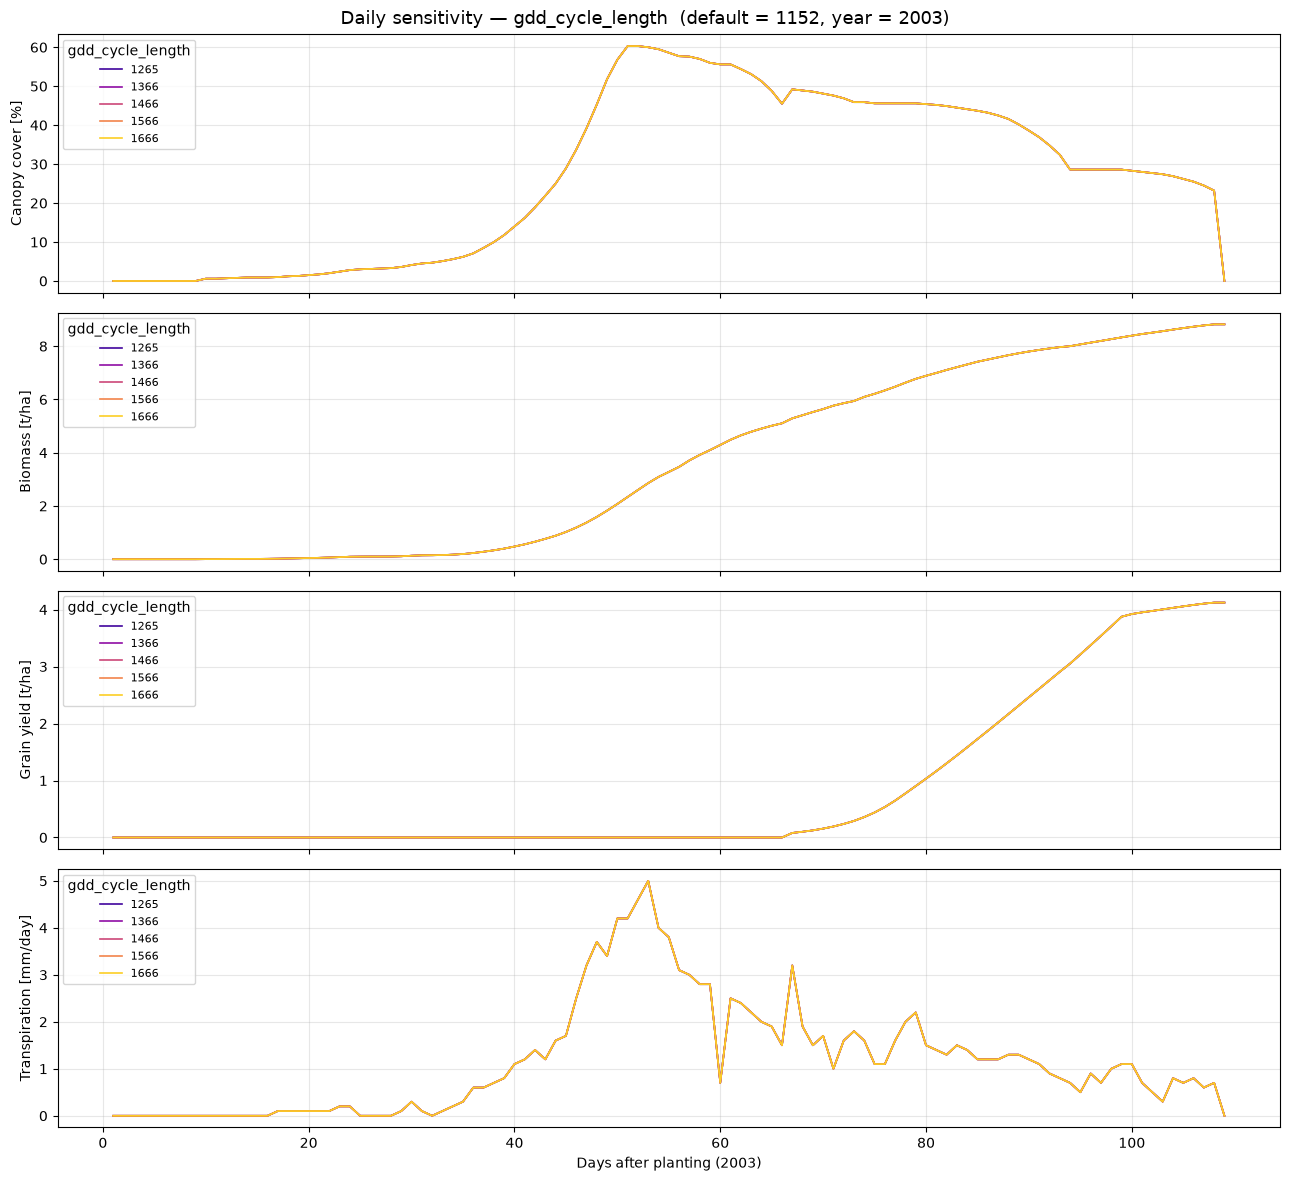

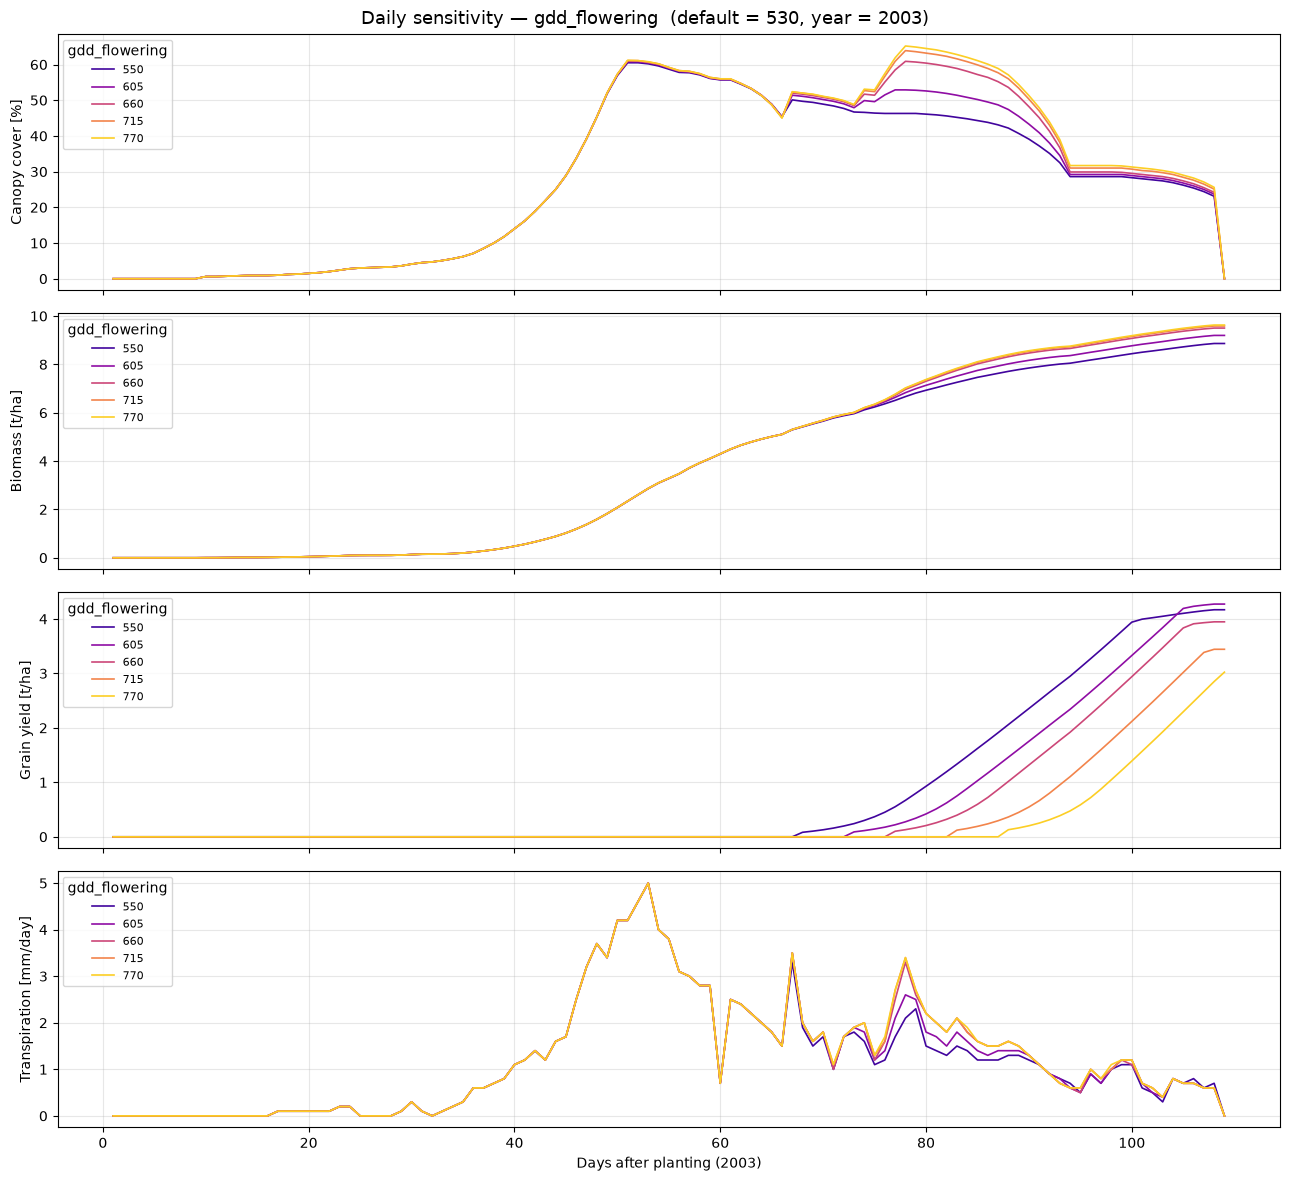

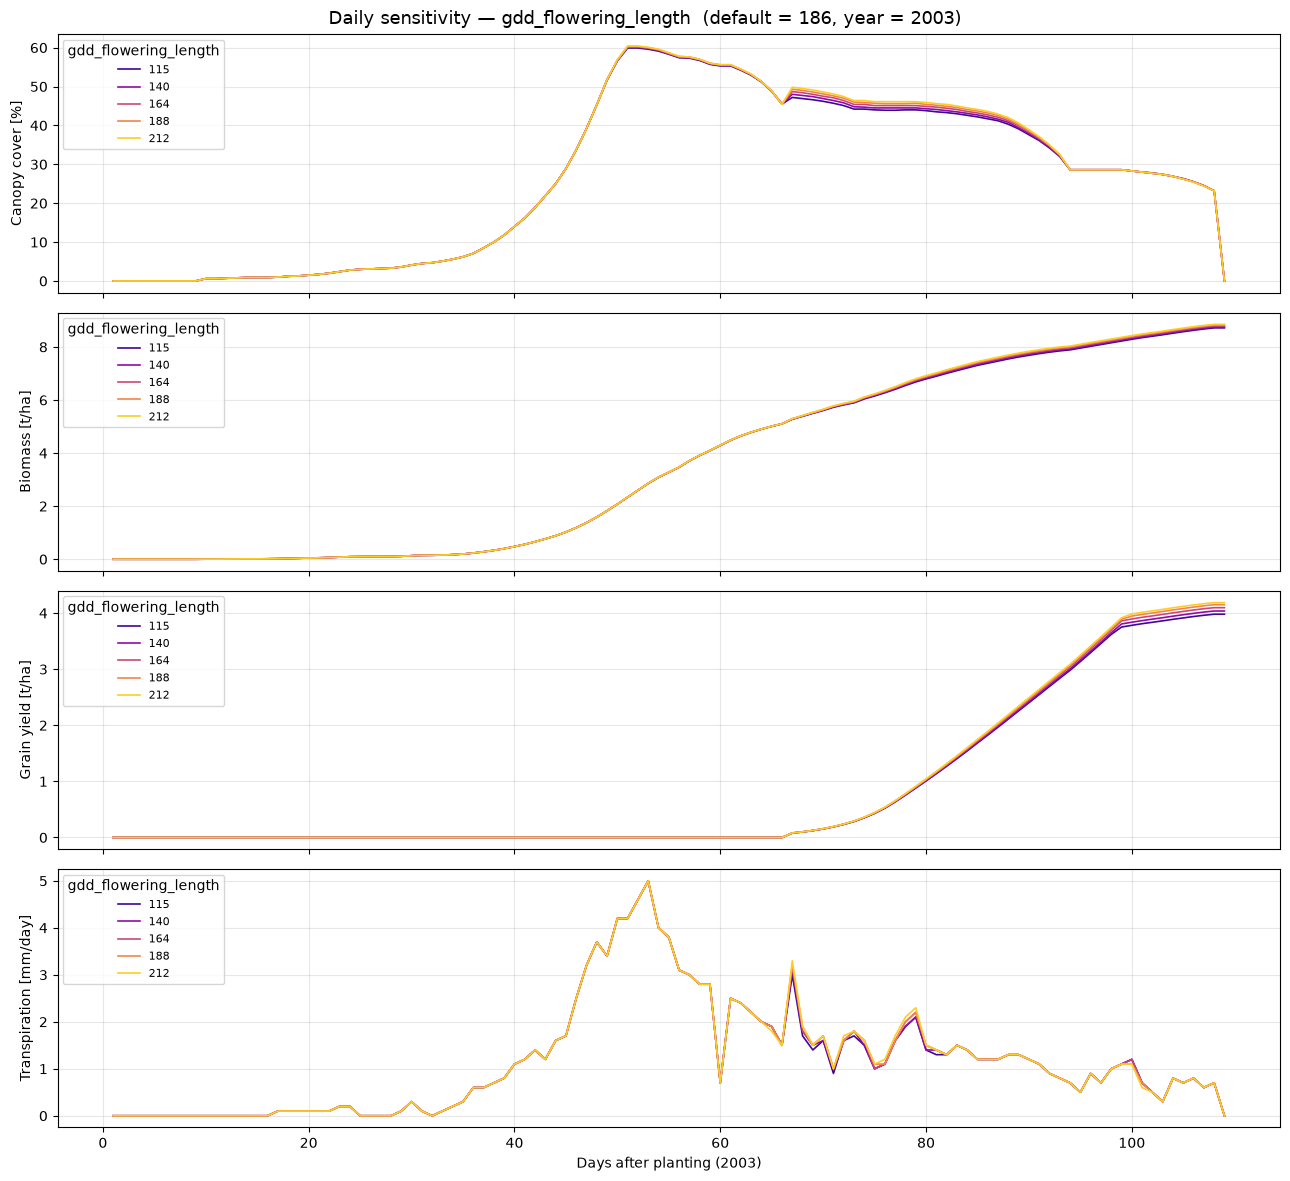

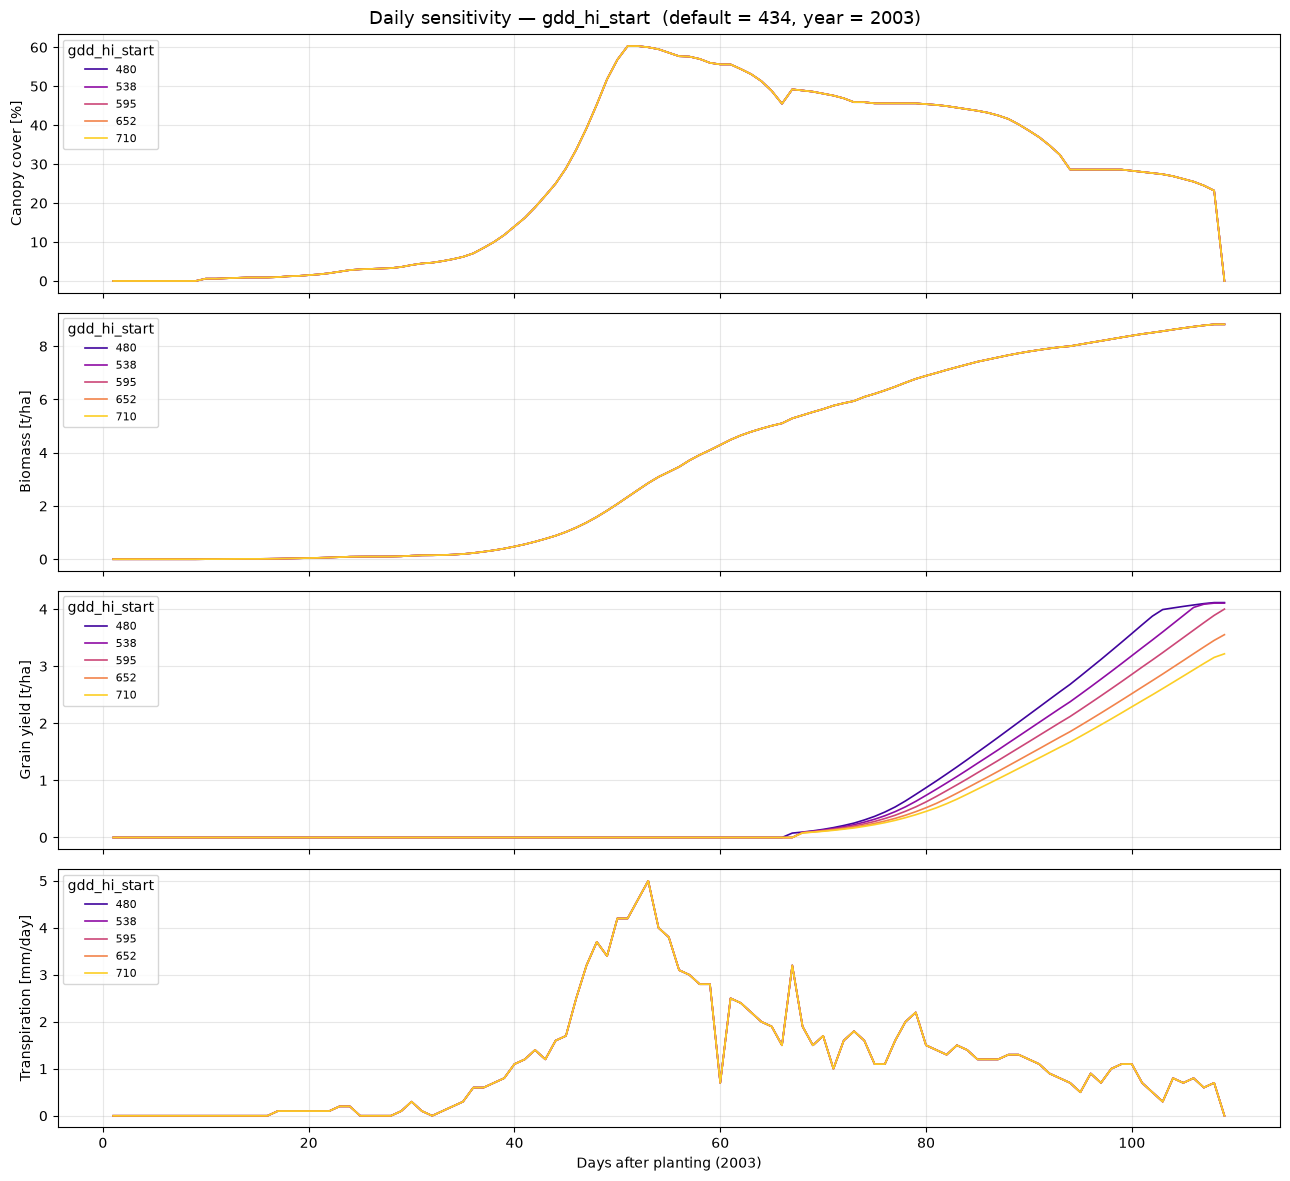

In [22]:
daily_panels = [
    ("CC",      "Canopy cover [%]"),
    ("Biomass", "Biomass [t/ha]"),
    ("Y(dry)",  "Grain yield [t/ha]"),
    ("Tr",      "Transpiration [mm/day]"),
]

for param_name, results_by_value in gdd_daily_results.items():
    values = sorted(results_by_value.keys())
    default_val = rakican_maize_params[param_name]
    colors = cm.plasma(np.linspace(0.1, 0.9, len(values)))

    fig, axes = plt.subplots(len(daily_panels), 1, figsize=(13, 3 * len(daily_panels)), sharex=True)
    fig.suptitle(
        f"Daily sensitivity — {param_name}  (default = {default_val}, year = {year})",
        fontsize=13,
    )

    for ax, (col, ylabel) in zip(axes, daily_panels):
        for val, color in zip(values, colors):
            daily = results_by_value[val]
            lw = 2.5 if val == default_val else 1.2
            ls = "--" if val == default_val else "-"
            ax.plot(
                daily["DAP"].values,
                daily[col].values,
                color=color,
                linewidth=lw,
                linestyle=ls,
                label=f"{val:.4g}" + (" (default)" if val == default_val else ""),
            )
        ax.set_ylabel(ylabel)
        ax.legend(title=param_name, fontsize=8, loc="upper left")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel(f"Days after planting ({year})")
    plt.tight_layout()
    plt.show()

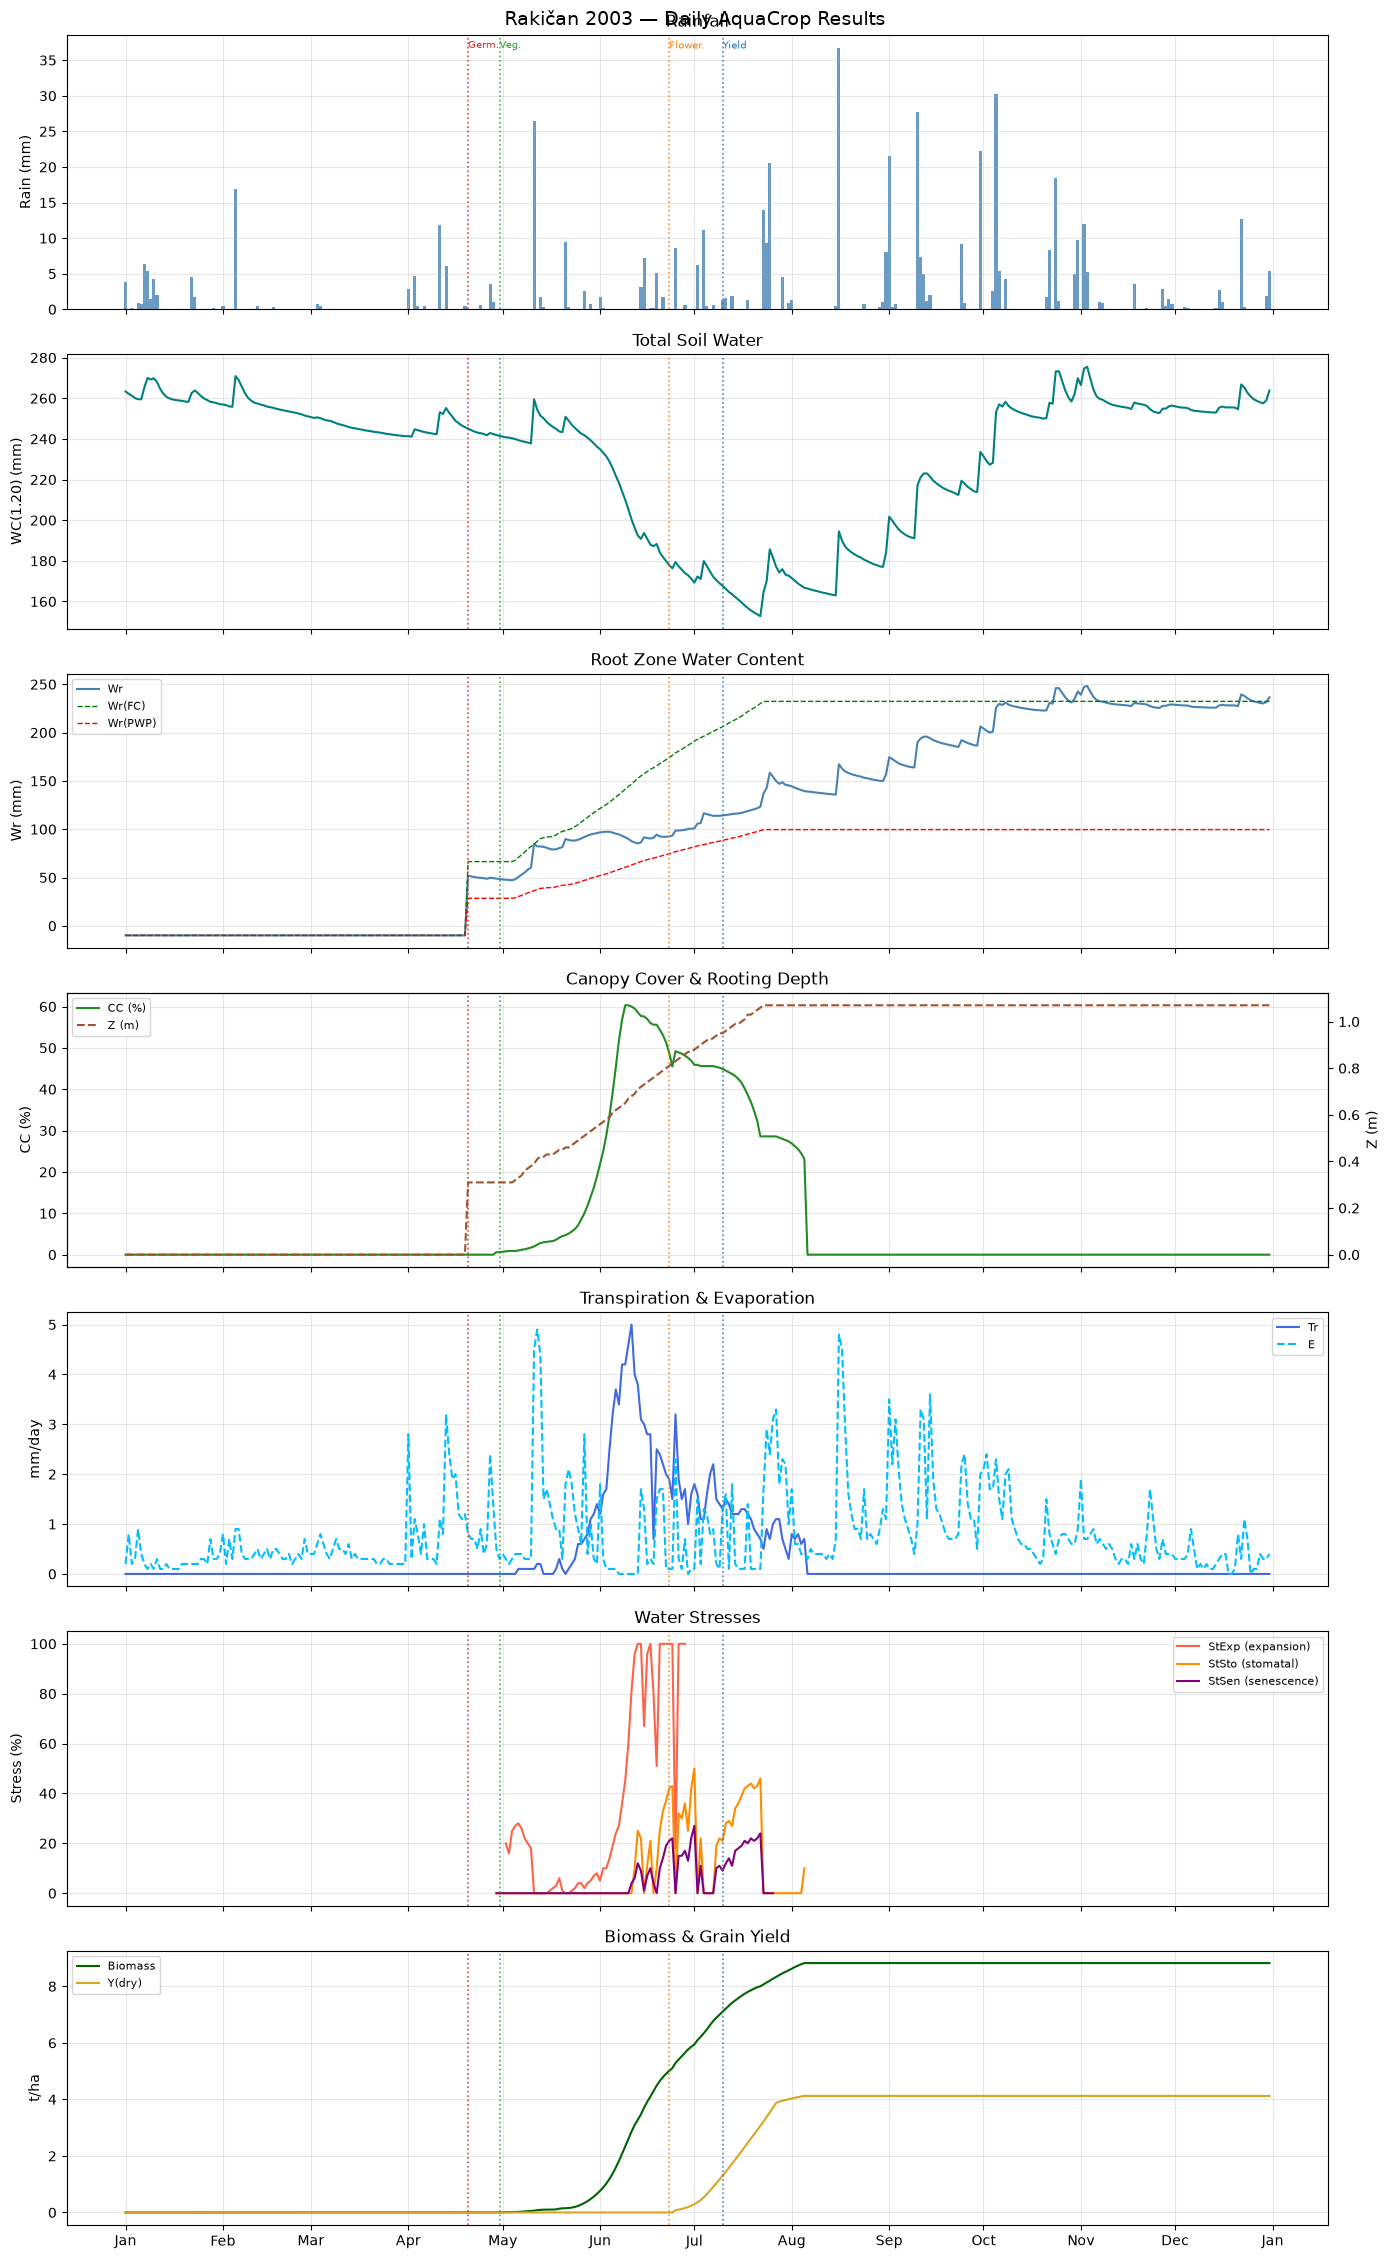

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from aquacrop.output import OutputReader as _DailyReader

_r = _DailyReader(output_dir=str(output_dir / "OUTP"))
_r.scan_directory()
day = _r.get_day_data(run_number=1)
day["date"] = pd.to_datetime(dict(year=day["Year"], month=day["Month"], day=day["Day"]))

def to_num(name):
    s = pd.to_numeric(day[name], errors="coerce")
    return s.where(s != -9)

wc_total_col = next(c for c in day.columns if c.startswith("WC("))

STAGE_LABELS = {1: "Germ.", 2: "Veg.", 3: "Flower.", 4: "Yield", 5: "Senes.", 6: "Mat."}
STAGE_COLORS = {1: "#d62728", 2: "#2ca02c", 3: "#ff7f0e", 4: "#1f77b4", 5: "#9467bd", 6: "#8c564b"}

stage_s = pd.to_numeric(day["Stage"], errors="coerce")
mask = (stage_s > 0) & (stage_s != stage_s.shift(1))
stage_transitions = day.loc[mask, ["date", "Stage"]].copy()
stage_transitions.loc[:, "Stage"] = stage_transitions["Stage"].astype(int)

fig, axes = plt.subplots(7, 1, figsize=(14, 23), sharex=True)
dates = day["date"]

ax = axes[0]
ax.bar(dates, to_num("Rain"), color="steelblue", alpha=0.8, width=1)
ax.set_ylabel("Rain (mm)")
ax.set_title("Rainfall")

ax = axes[1]
ax.plot(dates, to_num(wc_total_col), color="teal")
ax.set_ylabel(f"{wc_total_col} (mm)")
ax.set_title("Total Soil Water")

ax = axes[2]
ax.plot(dates, to_num("Wr"), color="steelblue", label="Wr")
ax.plot(dates, to_num("Wr(FC)"), color="green", linestyle="--", linewidth=1, label="Wr(FC)")
ax.plot(dates, to_num("Wr(PWP)"), color="red", linestyle="--", linewidth=1, label="Wr(PWP)")
ax.set_ylabel("Wr (mm)")
ax.legend(loc="upper left", fontsize=8)
ax.set_title("Root Zone Water Content")

ax = axes[3]
ax.plot(dates, to_num("CC"), color="forestgreen", label="CC (%)")
ax.set_ylabel("CC (%)")
ax2 = ax.twinx()
ax2.plot(dates, to_num("Z"), color="sienna", linestyle="--", label="Z (m)")
ax2.set_ylabel("Z (m)")
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, loc="upper left", fontsize=8)
ax.set_title("Canopy Cover & Rooting Depth")

ax = axes[4]
ax.plot(dates, to_num("Tr"), color="royalblue", label="Tr")
ax.plot(dates, to_num("E"), color="deepskyblue", linestyle="--", label="E")
ax.set_ylabel("mm/day")
ax.legend(loc="upper right", fontsize=8)
ax.set_title("Transpiration & Evaporation")

ax = axes[5]
ax.plot(dates, to_num("StExp"), color="tomato", label="StExp (expansion)")
ax.plot(dates, to_num("StSto"), color="darkorange", label="StSto (stomatal)")
ax.plot(dates, to_num("StSen"), color="purple", label="StSen (senescence)")
ax.set_ylabel("Stress (%)")
ax.legend(loc="upper right", fontsize=8)
ax.set_title("Water Stresses")

ax = axes[6]
ax.plot(dates, to_num("Biomass"), color="darkgreen", label="Biomass")
ax.plot(dates, to_num("Y(dry)"), color="goldenrod", label="Y(dry)")
ax.set_ylabel("t/ha")
ax.legend(loc="upper left", fontsize=8)
ax.set_title("Biomass & Grain Yield")

for ax in axes:
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.grid(True, alpha=0.3)

for _, row in stage_transitions.iterrows():
    s = row["Stage"]
    color = STAGE_COLORS.get(s, "gray")
    label = STAGE_LABELS.get(s, f"Stage {s}")
    for ax in axes:
        ax.axvline(row["date"], color=color, linestyle=":", linewidth=1.2, alpha=0.85)
    axes[0].text(
        row["date"], 0.98, label,
        transform=axes[0].get_xaxis_transform(),
        color=color, fontsize=7, ha="left", va="top",
    )

plt.suptitle(f"Rakičan {year} — Daily AquaCrop Results", fontsize=14)
plt.tight_layout()
plt.show()

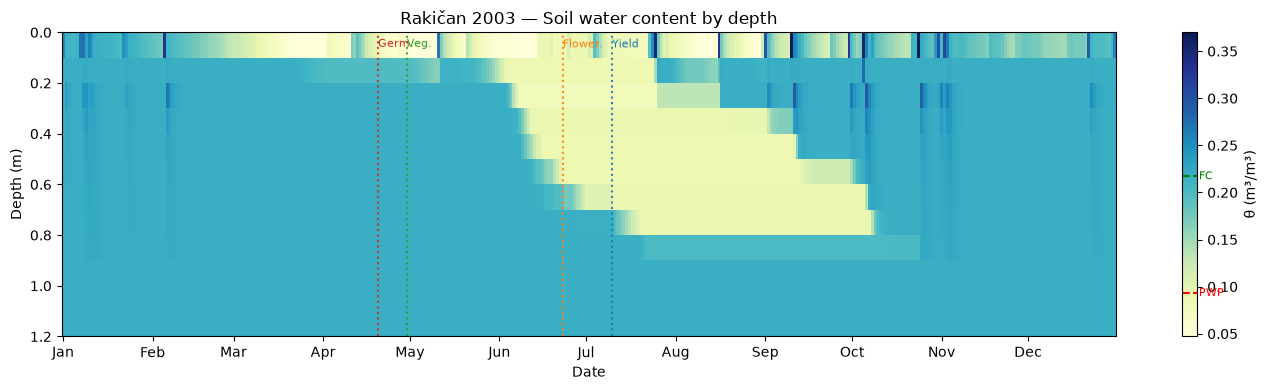

In [24]:
import pathlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.transforms as mtransforms
import numpy as np
import pandas as pd
from aquacrop.output import OutputReader
from aquacrop_slovenia.parameters_running_rakican import rakican_soil_layers

reader = OutputReader(output_dir=str(output_dir / "OUTP"))
reader.scan_directory()
all_days = reader.get_day_data(run_number=1)
all_days["date"] = pd.to_datetime(dict(year=all_days["Year"], month=all_days["Month"], day=all_days["Day"]))

wc_cols = ["WC01", "WC", "2", "WC_1", "3", "WC_2", "4", "WC_3", "5", "WC_4", "6", "WC_5"]

day_file = next(pathlib.Path(output_dir / "OUTP").glob("*day.OUT"))
with open(day_file) as f:
    units_line = f.readlines()[4]
numeric_units = []
for x in units_line.split():
    try:
        numeric_units.append(float(x))
    except ValueError:
        pass
centers = np.array(numeric_units[:12])

wc_total_col = next(c for c in all_days.columns if c.startswith("WC("))
total_depth = float(wc_total_col[3:-1])
bounds = np.concatenate([[0.0], (centers[:-1] + centers[1:]) / 2, [total_depth]])

wc    = all_days[wc_cols].values.astype(float)
theta = wc / 100

dates_num = mdates.date2num(all_days["date"].values)
x_edges = np.concatenate([[dates_num[0] - 0.5], dates_num + 0.5])

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.pcolormesh(x_edges, bounds, theta.T, cmap="YlGnBu", shading="flat")
ax.set_ylim(total_depth, 0)
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_xlabel("Date")
ax.set_ylabel("Depth (m)")
ax.set_title(f"Rakičan {year} — Soil water content by depth")

theta_fc  = rakican_soil_layers[0].fc / 100
theta_pwp = rakican_soil_layers[0].wp / 100

cb = plt.colorbar(im, ax=ax, label="θ (m³/m³)")
cb.ax.axhline(theta_fc,  color="green", linewidth=1.5, linestyle="--")
cb.ax.axhline(theta_pwp, color="red",   linewidth=1.5, linestyle="--")
trans = mtransforms.blended_transform_factory(cb.ax.transAxes, cb.ax.transData)
cb.ax.text(1.1, theta_fc,  "FC",  transform=trans, va="center", ha="left",
           fontsize=8, color="green", clip_on=False)
cb.ax.text(1.1, theta_pwp, "PWP", transform=trans, va="center", ha="left",
           fontsize=8, color="red",   clip_on=False)

STAGE_LABELS = {1: "Germ.", 2: "Veg.", 3: "Flower.", 4: "Yield", 5: "Senes.", 6: "Mat."}
STAGE_COLORS = {1: "#d62728", 2: "#2ca02c", 3: "#ff7f0e", 4: "#1f77b4", 5: "#9467bd", 6: "#8c564b"}

stage_s = pd.to_numeric(all_days["Stage"], errors="coerce")
mask = (stage_s > 0) & (stage_s != stage_s.shift(1))
transitions = all_days.loc[mask, ["date", "Stage"]].copy()
transitions.loc[:, "Stage"] = transitions["Stage"].astype(int)

for _, row in transitions.iterrows():
    s = row["Stage"]
    color = STAGE_COLORS.get(s, "gray")
    label = STAGE_LABELS.get(s, f"Stage {s}")
    ax.axvline(row["date"], color=color, linestyle=":", linewidth=1.5, alpha=0.9)
    ax.text(
        row["date"], 0.98, label,
        transform=ax.get_xaxis_transform(),
        color=color, fontsize=8, ha="left", va="top",
    )

plt.tight_layout()
plt.show()

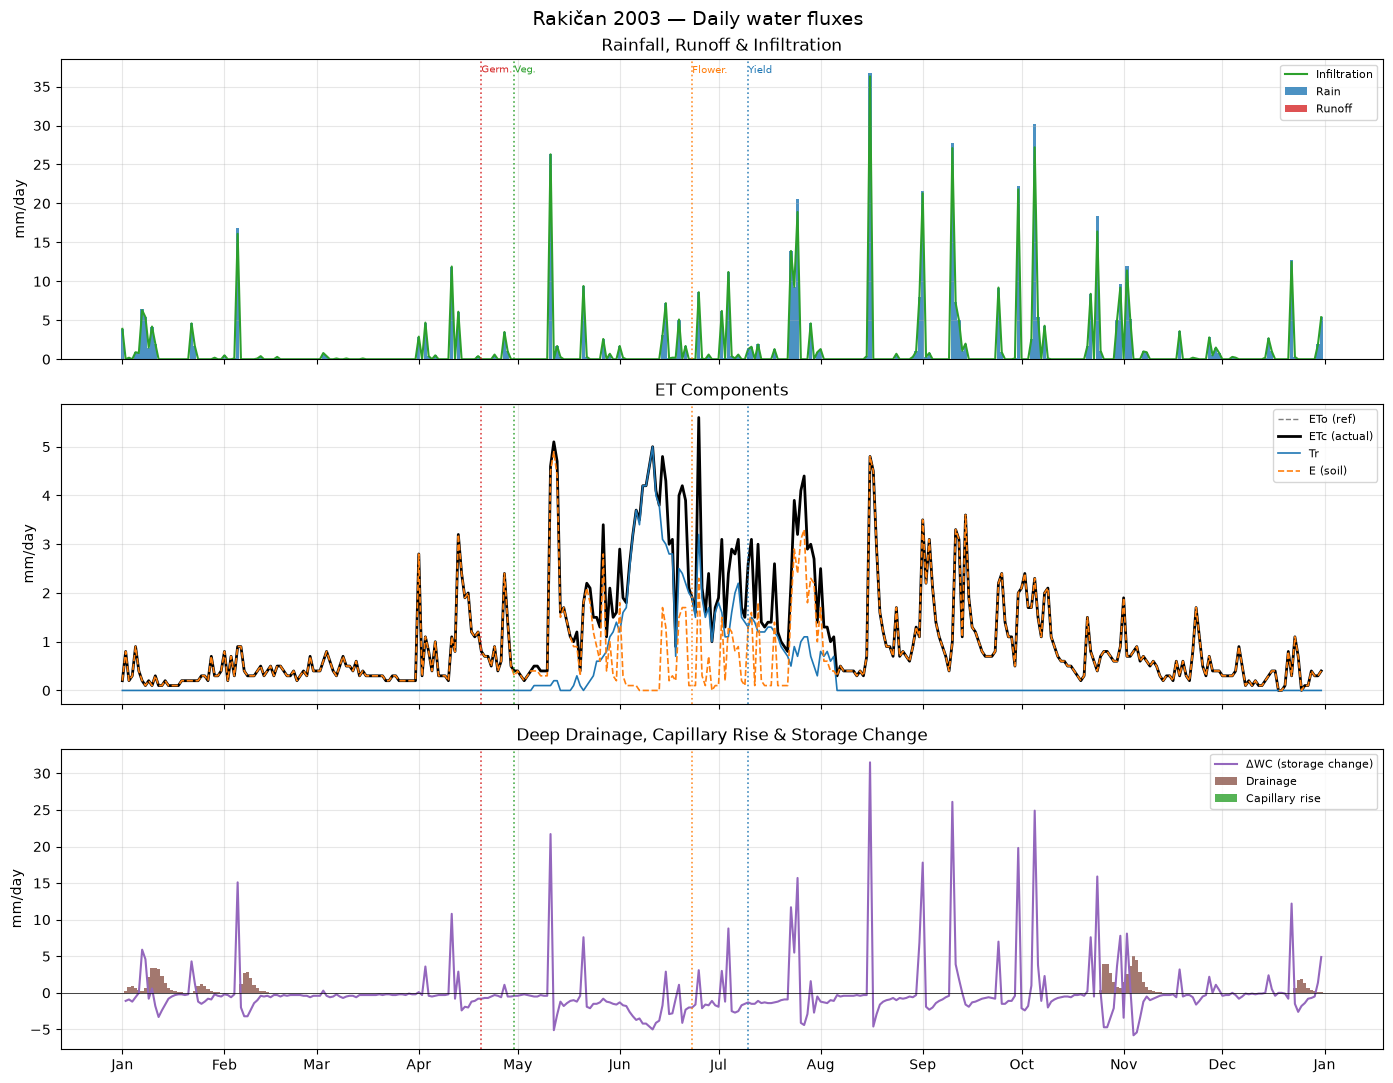

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle(f"Rakičan {year} — Daily water fluxes", fontsize=14)

_dates = day["date"]

# Rainfall, runoff, infiltration
ax = axes[0]
ax.bar(_dates, to_num("Rain"),    color="#1f77b4", alpha=0.8, width=1, label="Rain")
ax.bar(_dates, to_num("Surf"),    color="#d62728", alpha=0.8, width=1, label="Runoff")
ax.plot(_dates, to_num("Infilt"), color="#2ca02c", linewidth=1.5, label="Infiltration")
ax.set_ylabel("mm/day")
ax.legend(fontsize=8, loc="upper right")
ax.set_title("Rainfall, Runoff & Infiltration")

# ET components: actual vs potential
ax = axes[1]
ax.plot(_dates, to_num("ETo"), color="#7f7f7f", linestyle="--", linewidth=1,   label="ETo (ref)")
ax.plot(_dates, to_num("ET"),  color="#000000", linewidth=2,                   label="ETc (actual)")
ax.plot(_dates, to_num("Tr"),  color="#1f77b4", linewidth=1.2,                 label="Tr")
ax.plot(_dates, to_num("E"),   color="#ff7f0e", linestyle="--", linewidth=1.2, label="E (soil)")
ax.set_ylabel("mm/day")
ax.legend(fontsize=8, loc="upper right")
ax.set_title("ET Components")

# Deep drainage, capillary rise, storage change
ax = axes[2]
ax.bar(_dates, to_num("Drain"), color="#8c564b", alpha=0.8, width=1, label="Drainage")
ax.bar(_dates, to_num("CR"),    color="#2ca02c", alpha=0.8, width=1, label="Capillary rise")
ax.plot(_dates, pd.to_numeric(day[wc_total_col], errors="coerce").diff(),
        color="#9467bd", linewidth=1.5, label="ΔWC (storage change)")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("mm/day")
ax.legend(fontsize=8, loc="upper right")
ax.set_title("Deep Drainage, Capillary Rise & Storage Change")

for ax in axes:
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.grid(True, alpha=0.3)

for _, row in stage_transitions.iterrows():
    s = row["Stage"]
    color = STAGE_COLORS.get(s, "gray")
    label = STAGE_LABELS.get(s, f"Stage {s}")
    for ax in axes:
        ax.axvline(row["date"], color=color, linestyle=":", linewidth=1.2, alpha=0.85)
    axes[0].text(
        row["date"], 0.98, label,
        transform=axes[0].get_xaxis_transform(),
        color=color, fontsize=7, ha="left", va="top",
    )

plt.tight_layout()
plt.show()